# Configuración del Entorno e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, f1_score, recall_score, accuracy_score)
import xgboost as xgb
import optuna

# wilcoxon test for statistical significance
from scipy.stats import wilcoxon

print(f"XGBoost version: {xgb.__version__}")
print(f"GPU Support: {xgb.build_info()['USE_CUDA']}")
print(f"Optuna version: {optuna.__version__}")

sns.set_theme(style="whitegrid", context="paper")

XGBoost version: 3.3.0
GPU Support: True
Optuna version: 4.9.0


# Carga y Preprocesamiento de Datos
Cargamos el dataset "default of credit card clients", eliminamos la columna ID (sin poder predictivo) y renombramos la variable objetivo para mayor claridad.

In [2]:
# Cargar dataset
df = pd.read_csv('../../../Dataset/default of credit card clients.csv', sep=',', skiprows=1)

# Limpieza inicial
if 'default payment next month' in df.columns:
    df.rename(columns={'default payment next month': 'target'}, inplace=True)
if 'ID' in df.columns:
    df.drop('ID', axis=1, inplace=True)

print(f"Dimensiones del dataset: {df.shape}")
display(df.head())

Dimensiones del dataset: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


# División Train/Test y Cálculo de Scale Pos Weight
- Usamos 80% para entrenamiento y 20% para prueba, con estratificación para mantener la proporción de clases.
- Calculamos el peso para penalizar más los errores en la clase minoritaria (Incumple = 1).

In [3]:
# Separar variables
X = df.drop('target', axis=1)
y = df['target']

# Dividir en conjuntos de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Calcular el peso para balancear las clases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
base_scale_pos_weight = neg / pos

print(f"Tamaño del set de entrenamiento: {X_train.shape}")
print(f"Tamaño del set de prueba: {X_test.shape}")
print(f"Scale Pos Weight calculado (Base): {base_scale_pos_weight:.4f}")

Tamaño del set de entrenamiento: (24000, 23)
Tamaño del set de prueba: (6000, 23)
Scale Pos Weight calculado (Base): 3.5206


# Entrenamiento del Modelo Base XGBoost
Configuramos el modelo base con los hiperparámetros por defecto del notebook original, habilitando GPU.

In [4]:
model_base = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=base_scale_pos_weight,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)

model_base.fit(X_train, y_train, verbose=False)

# Predicciones
y_pred_base = model_base.predict(X_test)
y_pred_prob_base = model_base.predict_proba(X_test)[:, 1]

# Métricas Base
pr_auc_base = average_precision_score(y_test, y_pred_prob_base)
f1_base = f1_score(y_test, y_pred_base)
recall_base = recall_score(y_test, y_pred_base)
acc_base = accuracy_score(y_test, y_pred_base)

print(f"--- MÉTRICAS MODELO BASE ---")
print(f"PR-AUC: {pr_auc_base:.4f} | F1-Score: {f1_base:.4f} | Recall: {recall_base:.4f} | Accuracy: {acc_base:.4f}")

--- MÉTRICAS MODELO BASE ---
PR-AUC: 0.5459 | F1-Score: 0.5307 | Recall: 0.5870 | Accuracy: 0.7703


# Visualización del Modelo Base
Generamos la Matriz de Confusión, Curva ROC y Curva Precision-Recall para establecer la línea base.

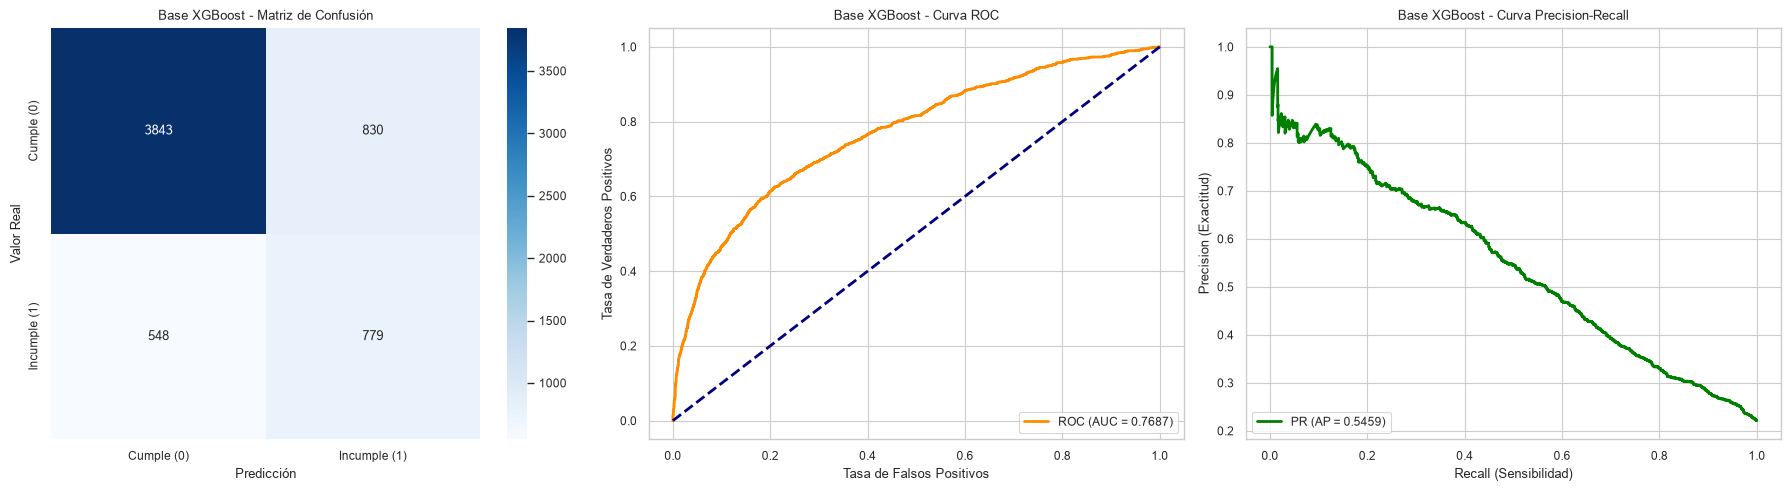

In [5]:
def plot_model_evaluation(y_test, y_pred, y_pred_prob, title_prefix="Modelo Base"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Matriz de Confusión
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Cumple (0)', 'Incumple (1)'],
                yticklabels=['Cumple (0)', 'Incumple (1)'])
    axes[0].set_title(f'{title_prefix} - Matriz de Confusión')
    axes[0].set_ylabel('Valor Real')
    axes[0].set_xlabel('Predicción')

    # 2. Curva ROC
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = roc_auc_score(y_test, y_pred_prob)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title(f'{title_prefix} - Curva ROC')
    axes[1].legend(loc="lower right")

    # 3. Curva Precision-Recall
    precision, recall, _ = precision_recall_curve(y_test, y_pred_prob)
    pr_auc = average_precision_score(y_test, y_pred_prob)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'PR (AP = {pr_auc:.4f})')
    axes[2].set_xlabel('Recall (Sensibilidad)')
    axes[2].set_ylabel('Precision (Exactitud)')
    axes[2].set_title(f'{title_prefix} - Curva Precision-Recall')
    axes[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

plot_model_evaluation(y_test, y_pred_base, y_pred_prob_base, title_prefix="Base XGBoost")

# Función Objetivo y Espacio de Búsqueda para Optuna
- Definimos el espacio de búsqueda para los hiperparámetros.
- La función objetivo **maximiza** el PR-AUC usando Validación Cruzada Estratificada (3 folds).
- Se usa early_stopping para acelerar la evaluación durante la búsqueda.

In [6]:
def objective_function_optuna(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 600),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.0, 5.0), 
        'tree_method': 'hist',
        'device': 'cuda',
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 30,
        'random_state': 42,
        'verbosity': 0
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in skf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        
        y_pred = model.predict(X_val)
        y_pred_prob = model.predict_proba(X_val)[:, 1]
        
        pr_auc = average_precision_score(y_val, y_pred_prob)
        f1 = f1_score(y_val, y_pred)
        recall = recall_score(y_val, y_pred)
        
        # Media Geométrica con Penalización
        combined_score = np.sqrt(pr_auc * f1)
        MIN_RECALL_THRESHOLD = 0.55
        if recall < MIN_RECALL_THRESHOLD:
            penalty = (MIN_RECALL_THRESHOLD - recall) * 0.8
        else:
            penalty = 0.0
            
        # Optuna MAXIMIZA, así que restamos la penalización
        final_score = combined_score - penalty
        scores.append(final_score)
        
    return np.mean(scores)

# Optimización Optuna - Escenario A
798 OFEs (266 trials * 3 folds CV = 798 OFEs)

In [7]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

study_A = optuna.create_study(direction='maximize', study_name="XGBoost_Optuna_Scenario_A")

study_A.optimize(objective_function_optuna, n_trials=266, show_progress_bar=True)


print("Optimización Escenario A (798 OFEs / 266 trials) completada")
print(f"Mejor PR-AUC (CV): {study_A.best_value:.4f}")
print(f"Mejores hiperparámetros encontrados: {study_A.best_params}")

best_params_A = study_A.best_params.copy()

  0%|          | 0/266 [00:00<?, ?it/s]

Optimización Escenario A (798 OFEs / 266 trials) completada
Mejor PR-AUC (CV): 0.5544
Mejores hiperparámetros encontrados: {'n_estimators': 341, 'max_depth': 6, 'learning_rate': 0.05308954041724079, 'subsample': 0.7448942921730894, 'colsample_bytree': 0.9369790886935763, 'scale_pos_weight': 3.157890671184428}


# Entrenamiento Final y Evaluación del Modelo Optuna (Escenario A)
Entrenamos el modelo final con los hiperparámetros óptimos sin early stopping agresivo para máxima precisión.

--- MÉTRICAS OPTUNA (Escenario A / 266 Trials) ---
PR-AUC: 0.5509 | F1-Score: 0.5364 | Recall: 0.5772 | Accuracy: 0.7793


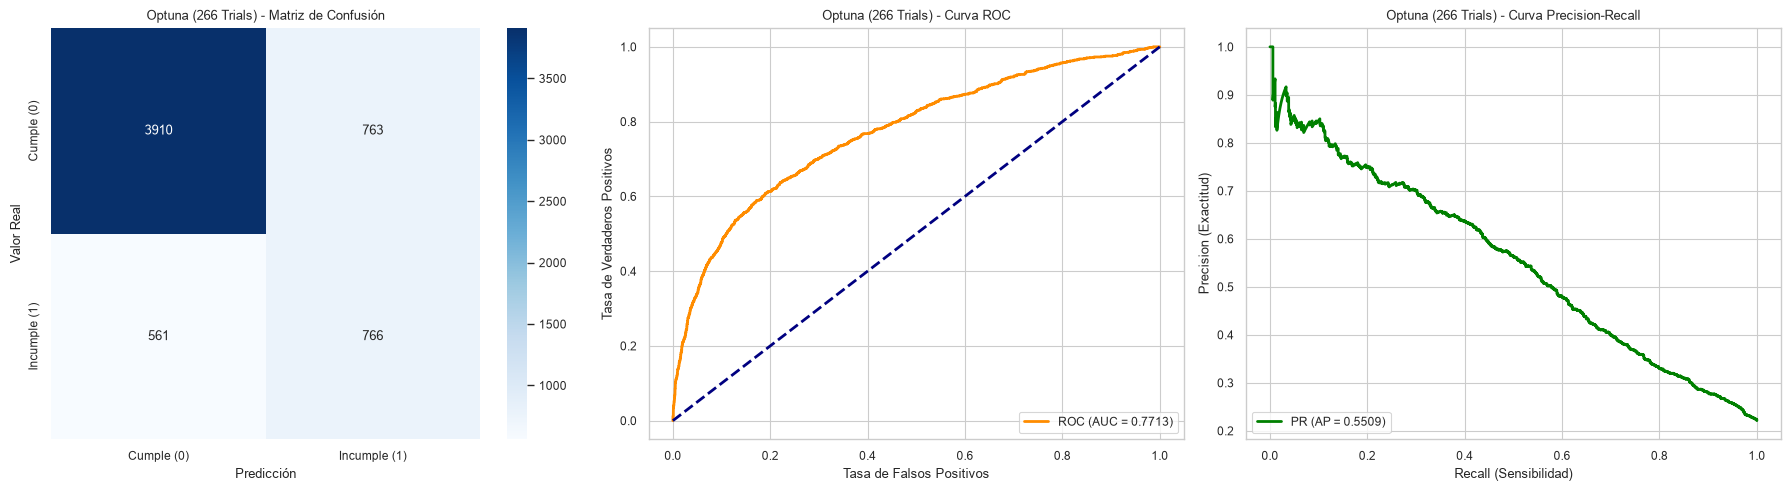

In [8]:
model_optuna_400 = xgb.XGBClassifier(
    **best_params_A,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
model_optuna_400.fit(X_train, y_train, verbose=False)

y_pred_optuna_400 = model_optuna_400.predict(X_test)
y_pred_prob_optuna_400 = model_optuna_400.predict_proba(X_test)[:, 1]

pr_auc_400 = average_precision_score(y_test, y_pred_prob_optuna_400)
f1_400 = f1_score(y_test, y_pred_optuna_400)
recall_400 = recall_score(y_test, y_pred_optuna_400)
acc_400 = accuracy_score(y_test, y_pred_optuna_400)

print(f"--- MÉTRICAS OPTUNA (Escenario A / 266 Trials) ---")
print(f"PR-AUC: {pr_auc_400:.4f} | F1-Score: {f1_400:.4f} | Recall: {recall_400:.4f} | Accuracy: {acc_400:.4f}")

plot_model_evaluation(y_test, y_pred_optuna_400, y_pred_prob_optuna_400, title_prefix="Optuna (266 Trials)")

# Optimización Optuna - Escenario B
~1000 OFEs (333 trials * 3 folds CV = 999 OFEs)

In [9]:
study_B = optuna.create_study(direction='maximize', study_name="XGBoost_Optuna_Scenario_B")

study_B.optimize(objective_function_optuna, n_trials=333, show_progress_bar=True)


print("Optimización 333 trials completada.")
print(f"Mejor PR-AUC (CV): {study_B.best_value:.4f}")
print(f"Mejores hiperparámetros encontrados: {study_B.best_params}")

best_params_B = study_B.best_params.copy()

  0%|          | 0/333 [00:00<?, ?it/s]

Optimización 333 trials completada.
Mejor PR-AUC (CV): 0.5548
Mejores hiperparámetros encontrados: {'n_estimators': 584, 'max_depth': 6, 'learning_rate': 0.018293837249205473, 'subsample': 0.6889204228850622, 'colsample_bytree': 0.8720929779771573, 'scale_pos_weight': 3.102495205973133}


# Entrenamiento Final y Evaluación del Modelo Optuna (Escenario B)

--- MÉTRICAS OPTUNA (333 Trials) ---
PR-AUC: 0.5541 | F1-Score: 0.5357 | Recall: 0.5705 | Accuracy: 0.7813


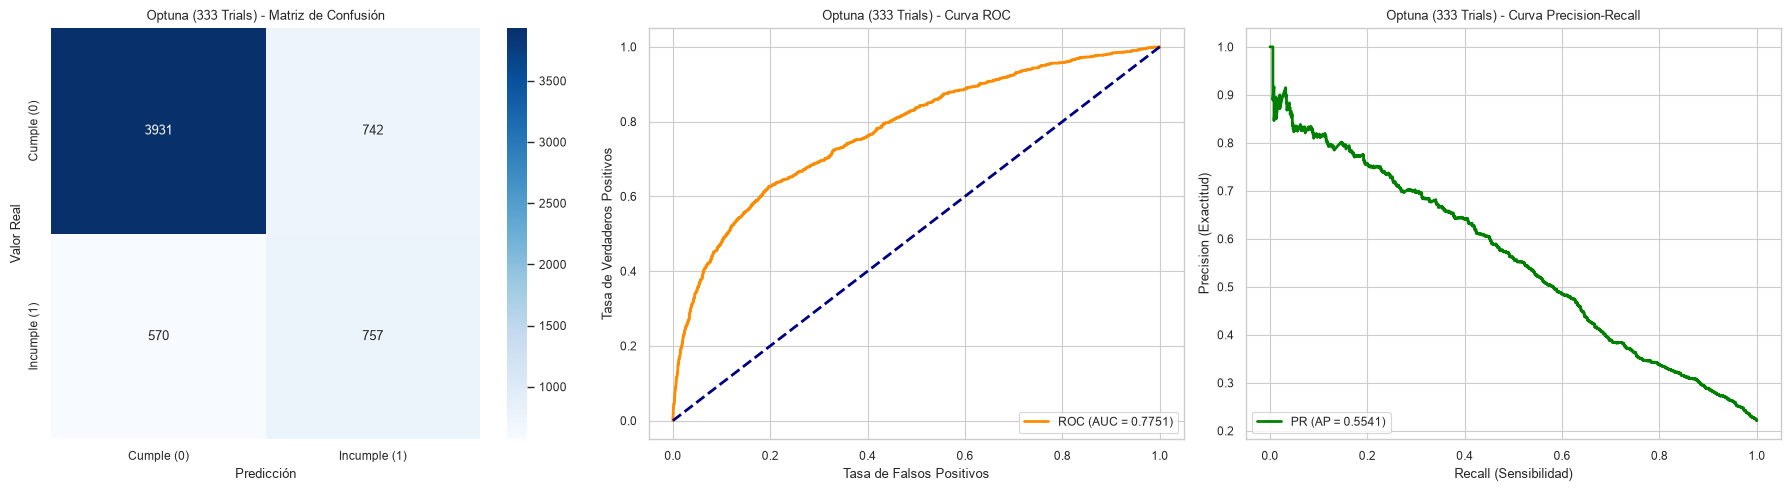

In [10]:
model_optuna_B = xgb.XGBClassifier(
    **best_params_B,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr',
    random_state=42,
    verbosity=0
)
model_optuna_B.fit(X_train, y_train, verbose=False)

y_pred_optuna_B = model_optuna_B.predict(X_test)
y_pred_prob_optuna_B = model_optuna_B.predict_proba(X_test)[:, 1]

pr_auc_B = average_precision_score(y_test, y_pred_prob_optuna_B)
f1_B = f1_score(y_test, y_pred_optuna_B)
recall_B = recall_score(y_test, y_pred_optuna_B)
acc_B = accuracy_score(y_test, y_pred_optuna_B)

print(f"--- MÉTRICAS OPTUNA (333 Trials) ---")
print(f"PR-AUC: {pr_auc_B:.4f} | F1-Score: {f1_B:.4f} | Recall: {recall_B:.4f} | Accuracy: {acc_B:.4f}")

plot_model_evaluation(y_test, y_pred_optuna_B, y_pred_prob_optuna_B, title_prefix="Optuna (333 Trials)")

# Tabla Comparativa de Rendimiento
Consolidamos las métricas para su inclusión directa en el paper.

In [11]:
comparison_df = pd.DataFrame({
    "Modelo": ["XGBoost Base", "Optuna Esc. A (266 Trials)", "Optuna Esc. B (333 Trials)"],
    "PR-AUC": [pr_auc_base, pr_auc_400, pr_auc_B],
    "F1-Score": [f1_base, f1_400, f1_B],
    "Recall": [recall_base, recall_400, recall_B],
    "Accuracy": [acc_base, acc_400, acc_B]
})

# Resaltar la mejora porcentual respecto al base
comparison_df["Mejora PR-AUC"] = comparison_df["PR-AUC"].apply(lambda x: f"+{((x/pr_auc_base)-1)*100:.2f}%")

print("\n📊 TABLA COMPARATIVA DE RENDIMIENTO")
display(comparison_df.style.highlight_max(subset=["PR-AUC", "F1-Score", "Recall", "Accuracy"], color='green'))


📊 TABLA COMPARATIVA DE RENDIMIENTO


,Modelo,PR-AUC,F1-Score,Recall,Accuracy,Mejora PR-AUC
0,XGBoost Base,0.545869,0.530654,0.587038,0.770333,+0.00%
1,Optuna Esc. A (266 Trials),0.550924,0.536415,0.577242,0.779333,+0.93%
2,Optuna Esc. B (333 Trials),0.554077,0.535740,0.570460,0.781333,+1.50%


# Análisis de Robustez Estadística
- Ejecutamos Optuna (50 y 100 trials) 15 veces con diferentes semillas aleatorias.
- Esto demuestra que la mejora no es un golpe de suerte, sino que el algoritmo es estable (varianza baja).
- NOTA: Esta celda puede tomar varios minutos debido a las múltiples evaluaciones de modelo por ejecución.

In [12]:
# semilla para reproducibilidad
seeds = [42, 123, 456, 789, 1011, 1213, 1415, 1617, 1819, 2021, 2223, 2425, 2627, 2829, 3031]

results_base_robust = []
results_optuna_A_robust = [] 
results_optuna_B_robust = [] 

print("Iniciando análisis de robustez (15 ejecuciones por configuración)...")

for i, seed in enumerate(seeds):
    print(f"  Ejecución {i+1}/15 (Seed: {seed})")

    # 1. Modelo Base con semilla variable
    mb = xgb.XGBClassifier(n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8,
                           colsample_bytree=0.8, scale_pos_weight=base_scale_pos_weight,
                           tree_method='hist', device='cuda', eval_metric='aucpr',
                           random_state=seed, verbosity=0)
    mb.fit(X_train, y_train, verbose=False)
    results_base_robust.append(average_precision_score(y_test, mb.predict_proba(X_test)[:, 1]))

    # 2. Función Objetivo para Robustez
    def make_obj_optuna_robust(seed_val):
        def obj(trial):
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 600),
                'max_depth': trial.suggest_int('max_depth', 3, 10),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
                'subsample': trial.suggest_float('subsample', 0.6, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
                'scale_pos_weight': trial.suggest_float('scale_pos_weight', 2.0, 5.0), # BÚSQUEDA LIBRE
                'tree_method': 'hist', 'device': 'cuda', 'eval_metric': 'aucpr',
                'early_stopping_rounds': 30, 'random_state': seed_val, 'verbosity': 0
            }
            skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed_val)
            scores = []
            for train_idx, val_idx in skf.split(X_train, y_train):
                X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                m = xgb.XGBClassifier(**params)
                m.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
                
                y_p = m.predict(X_val)
                y_p_prob = m.predict_proba(X_val)[:, 1]
                pr_auc = average_precision_score(y_val, y_p_prob)
                f1 = f1_score(y_val, y_p)
                recall = recall_score(y_val, y_p)
                
                combined_score = np.sqrt(pr_auc * f1)
                penalty = max(0.0, (0.55 - recall) * 0.8) if recall < 0.55 else 0.0
                scores.append(combined_score - penalty)
            return np.mean(scores)
        return obj

    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    # 3. Escenario A (266 Trials = ~798 OFEs)
    study_r_A = optuna.create_study(direction='maximize')
    study_r_A.optimize(make_obj_optuna_robust(seed), n_trials=266, show_progress_bar=False)
    best_p_A = study_r_A.best_params
    m_final_A = xgb.XGBClassifier(**best_p_A, tree_method='hist', device='cuda', eval_metric='aucpr', random_state=seed, verbosity=0)
    m_final_A.fit(X_train, y_train, verbose=False) # SIN EVAL_SET
    results_optuna_A_robust.append(average_precision_score(y_test, m_final_A.predict_proba(X_test)[:, 1]))

    # 4. Escenario B (333 Trials = ~1000 OFEs)
    study_r_B = optuna.create_study(direction='maximize')
    study_r_B.optimize(make_obj_optuna_robust(seed), n_trials=333, show_progress_bar=False)
    best_p_B = study_r_B.best_params
    m_final_B = xgb.XGBClassifier(**best_p_B, tree_method='hist', device='cuda', eval_metric='aucpr', random_state=seed, verbosity=0)
    m_final_B.fit(X_train, y_train, verbose=False) # SIN EVAL_SET
    results_optuna_B_robust.append(average_precision_score(y_test, m_final_B.predict_proba(X_test)[:, 1]))

print("Análisis de robustez completado.")

Iniciando análisis de robustez (15 ejecuciones por configuración)...
  Ejecución 1/15 (Seed: 42)
  Ejecución 2/15 (Seed: 123)
  Ejecución 3/15 (Seed: 456)
  Ejecución 4/15 (Seed: 789)
  Ejecución 5/15 (Seed: 1011)
  Ejecución 6/15 (Seed: 1213)
  Ejecución 7/15 (Seed: 1415)
  Ejecución 8/15 (Seed: 1617)
  Ejecución 9/15 (Seed: 1819)
  Ejecución 10/15 (Seed: 2021)
  Ejecución 11/15 (Seed: 2223)
  Ejecución 12/15 (Seed: 2425)
  Ejecución 13/15 (Seed: 2627)
  Ejecución 14/15 (Seed: 2829)
  Ejecución 15/15 (Seed: 3031)
Análisis de robustez completado.


# Boxplots PR-AUC
- Los "bigotes" cortos indican un algoritmo confiable y con baja varianza.
- Se compara la distribución de 15 ejecuciones de cada configuración.

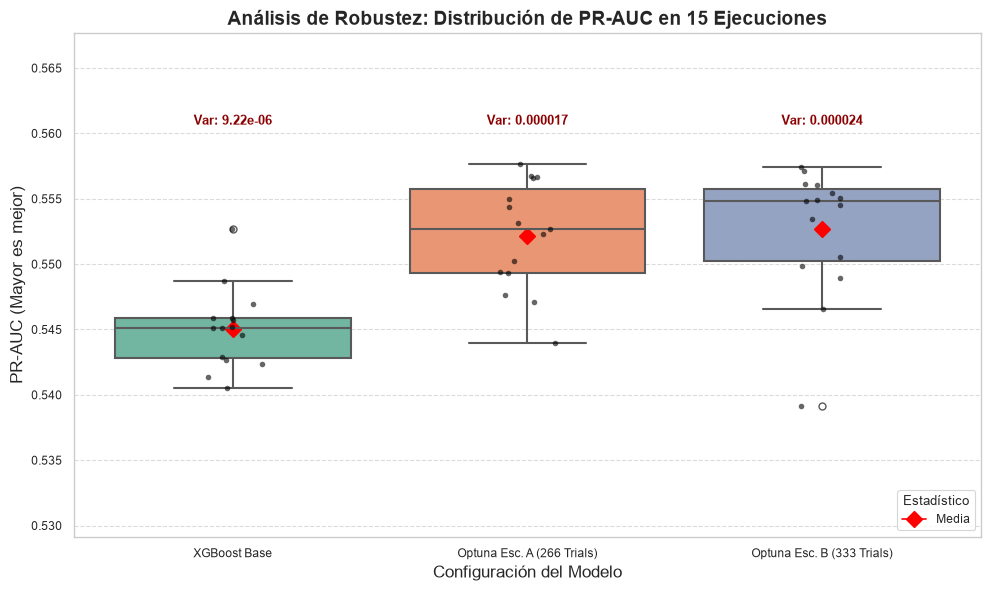

In [13]:
plt.figure(figsize=(10, 6))

# Preparar datos para seaborn
df_robust = pd.DataFrame({
    "XGBoost Base": results_base_robust,
    "Optuna Esc. A (266 Trials)": results_optuna_A_robust,
    "Optuna Esc. B (333 Trials)": results_optuna_B_robust
}).melt(var_name="Modelo", value_name="PR-AUC")

# Crear boxplot
ax = sns.boxplot(data=df_robust, x="Modelo", y="PR-AUC", palette="Set2",
                 linewidth=1.5, fliersize=5)
sns.stripplot(data=df_robust, x="Modelo", y="PR-AUC", color="black",
              size=4, alpha=0.6, jitter=True)

# Calcular estadísticos
models = df_robust["Modelo"].unique()
means = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].mean() for model in models]
variances = [df_robust[df_robust["Modelo"] == model]["PR-AUC"].var() for model in models]

# Añadir medias como puntos destacados
for i, (model, mean) in enumerate(zip(models, means)):
    ax.plot(i, mean, marker='D', color='red', markersize=8,
            label='Media' if i==0 else "")

plt.title("Análisis de Robustez: Distribución de PR-AUC en 15 Ejecuciones",
          fontsize=14, fontweight='bold')
plt.ylabel("PR-AUC (Mayor es mejor)", fontsize=12)
plt.xlabel("Configuración del Modelo", fontsize=12)
plt.ylim(min(df_robust["PR-AUC"]) - 0.01, max(df_robust["PR-AUC"]) + 0.01)
plt.legend(title="Estadístico", loc="lower right")
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Anotación de varianza
for i, (model, var, mean_val) in enumerate(zip(models, variances, means)):
    if var < 0.00001:
        var_text = f'Var: {var:.2e}'
    else:
        var_text = f'Var: {var:.6f}'

    ax.annotate(var_text, xy=(i, mean_val), xytext=(i, max(df_robust["PR-AUC"]) + 0.003),
                 ha='center', fontsize=9, color='darkred', fontweight='bold')

plt.tight_layout()
plt.show()

# Test de Significancia Estadística (Wilcoxon)
- Aplicamos la prueba no paramétrica de Wilcoxon para pares relacionados.
- Hipótesis Nula (H0): No hay diferencia significativa en el PR-AUC entre los modelos.
- Hipótesis Alternativa (H1): El modelo optimizado con Optuna es estadísticamente superior.
- Un p-value < 0.05 nos permite rechazar H0 y afirmar que la mejora NO es por azar.

In [14]:
# Optuna Escenario A vs Base
stat_A, p_A = wilcoxon(results_optuna_A_robust, results_base_robust, alternative='greater')
print(f"\n1. Optuna Esc. A (266 Trials) vs XGBoost Base:")
print(f"   Estadístico W: {stat_A:.4f}")
print(f"   p-value: {p_A:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_A < 0.05 else '❌ NO SIGNIFICATIVO'}")

# Optuna Escenario B vs Base
stat_B, p_B = wilcoxon(results_optuna_B_robust, results_base_robust, alternative='greater')
print(f"\n2. Optuna Esc. B (333 Trials) vs XGBoost Base:")
print(f"   Estadístico W: {stat_B:.4f}")
print(f"   p-value: {p_B:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_B < 0.05 else '❌ NO SIGNIFICATIVO'}")

# Optuna Escenario B vs Escenario A
stat_BvsA, p_BvsA = wilcoxon(results_optuna_B_robust, results_optuna_A_robust, alternative='greater')
print(f"\n3. Optuna Esc. B (333 Trials) vs Optuna Esc. A (266 Trials):")
print(f"   Estadístico W: {stat_BvsA:.4f}")
print(f"   p-value: {p_BvsA:.6f}  {'✅ SIGNIFICATIVO (p < 0.05)' if p_BvsA < 0.05 else '❌ NO SIGNIFICATIVO'}")


1. Optuna Esc. A (266 Trials) vs XGBoost Base:
   Estadístico W: 114.0000
   p-value: 0.000427  ✅ SIGNIFICATIVO (p < 0.05)

2. Optuna Esc. B (333 Trials) vs XGBoost Base:
   Estadístico W: 115.0000
   p-value: 0.000305  ✅ SIGNIFICATIVO (p < 0.05)

3. Optuna Esc. B (333 Trials) vs Optuna Esc. A (266 Trials):
   Estadístico W: 61.0000
   p-value: 0.488983  ❌ NO SIGNIFICATIVO
